# 05 — Markov Chains, Bigram Language Models, and HMMs

Probabilistic sequence models with a toy language model and POS tagger.

## Learning objectives

You will learn to:

- define a first-order Markov chain and transition matrix;
- simulate state sequences and inspect long-run distributions;
- train a smoothed bigram language model;
- compute sentence log-probability and perplexity;
- formulate an HMM using hidden states, emissions, and transitions;
- implement the Viterbi algorithm for toy POS tagging;
- understand what assumptions these models make about language.

In [1]:
from collections import Counter, defaultdict
import math
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 1. Markov chains

A first-order Markov chain assumes

$$
P(S_t\mid S_{1:t-1})=P(S_t\mid S_{t-1}).
$$

The future depends on the present state, not the complete path, once the present is known.

For finite states, transition probabilities form a matrix $A$:

$$
A_{ij}=P(S_t=j\mid S_{t-1}=i).
$$

Each row sums to 1.

In [2]:
states = ['sunny', 'cloudy', 'rainy']
A = np.array([
    [0.70, 0.20, 0.10],
    [0.30, 0.40, 0.30],
    [0.20, 0.30, 0.50],
])

print('Row sums:', A.sum(axis=1))

Row sums: [1. 1. 1.]


{'sunny': np.float64(0.457), 'cloudy': np.float64(0.283), 'rainy': np.float64(0.259)}


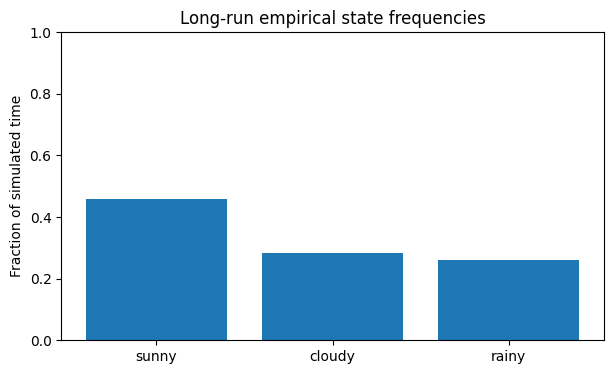

In [3]:
def simulate_markov_chain(transition_matrix, start_state, steps, rng):
    sequence = [start_state]
    current = start_state
    for _ in range(steps - 1):
        current = rng.choice(len(transition_matrix), p=transition_matrix[current])
        sequence.append(current)
    return np.array(sequence)

sequence = simulate_markov_chain(A, start_state=0, steps=20000, rng=rng)
empirical = np.bincount(sequence, minlength=len(states)) / len(sequence)
print(dict(zip(states, empirical.round(3))))

plt.figure(figsize=(7, 4))
plt.bar(states, empirical)
plt.ylabel('Fraction of simulated time')
plt.title('Long-run empirical state frequencies')
plt.ylim(0, 1)
plt.show()

### Stationary distribution

A stationary row vector $\pi$ satisfies

$$
\pi=\pi A,\qquad \sum_i\pi_i=1.
$$

Under suitable irreducibility and aperiodicity conditions, long-run state frequencies converge to this distribution.

In [4]:
eigenvalues, eigenvectors = np.linalg.eig(A.T)
stationary = np.real(eigenvectors[:, np.argmin(np.abs(eigenvalues - 1))])
stationary = stationary / stationary.sum()
print('Stationary distribution:', dict(zip(states, stationary.round(3))))

Stationary distribution: {'sunny': np.float64(0.457), 'cloudy': np.float64(0.283), 'rainy': np.float64(0.261)}


## 2. Bigram language models

A language model assigns probabilities to token sequences. The chain rule gives

$$
P(w_1,\ldots,w_T)=\prod_{t=1}^{T}P(w_t\mid w_1,\ldots,w_{t-1}).
$$

A bigram model makes a first-order approximation:

$$
P(w_t\mid w_1,\ldots,w_{t-1})\approx P(w_t\mid w_{t-1}).
$$

This is a Markov assumption over observed word tokens.

In [5]:
corpus = [
    'the cat sat on the mat',
    'the cat ate the fish',
    'the dog sat on the rug',
    'the dog ate the food',
    'a cat chased a mouse',
    'a dog chased the cat',
]

def tokenize(sentence):
    return sentence.lower().split()

sentences = [['<s>'] + tokenize(sentence) + ['</s>'] for sentence in corpus]
for sentence in sentences[:2]:
    print(sentence)

['<s>', 'the', 'cat', 'sat', 'on', 'the', 'mat', '</s>']
['<s>', 'the', 'cat', 'ate', 'the', 'fish', '</s>']


In [6]:
unigram_counts = Counter()
bigram_counts = Counter()

for sentence in sentences:
    unigram_counts.update(sentence[:-1])
    bigram_counts.update(zip(sentence[:-1], sentence[1:]))

print('Most common bigrams:')
for bigram, count in bigram_counts.most_common(10):
    print(bigram, count)

Most common bigrams:
('<s>', 'the') 4
('the', 'cat') 3
('sat', 'on') 2
('on', 'the') 2
('ate', 'the') 2
('the', 'dog') 2
('<s>', 'a') 2
('cat', 'sat') 1
('the', 'mat') 1
('mat', '</s>') 1


## 3. Maximum-likelihood estimation and smoothing

Without smoothing,

$$
\widehat P(w_t=v\mid w_{t-1}=u)=\frac{C(u,v)}{C(u)}.
$$

An unseen bigram receives probability zero, making an entire sentence probability zero. Add-$\alpha$ smoothing gives

$$
P(v\mid u)=\frac{C(u,v)+\alpha}{C(u)+\alpha |V|}.
$$

Add-one smoothing is simple but often too aggressive in real NLP. It is pedagogically useful.

In [7]:
vocabulary = sorted({token for sentence in sentences for token in sentence if token != '<s>'})
V = len(vocabulary)


def bigram_probability(previous, current, alpha=1.0):
    return (bigram_counts[(previous, current)] + alpha) / (unigram_counts[previous] + alpha * V)

for pair in [('the', 'cat'), ('the', 'mouse'), ('cat', '</s>')]:
    print(pair, bigram_probability(*pair, alpha=0.5))

('the', 'cat') 0.21875
('the', 'mouse') 0.03125
('cat', '</s>') 0.13636363636363635


In [8]:
def sentence_log_probability(sentence, alpha=0.5):
    tokens = ['<s>'] + tokenize(sentence) + ['</s>']
    return sum(math.log(bigram_probability(a, b, alpha)) for a, b in zip(tokens[:-1], tokens[1:]))

examples = ['the cat ate the fish', 'fish the ate cat the']
for sentence in examples:
    logp = sentence_log_probability(sentence)
    print(f'{sentence!r}: log probability={logp:.3f}')

'the cat ate the fish': log probability=-9.895
'fish the ate cat the': log probability=-18.944


## 4. Perplexity

For a sequence of $N$ predicted tokens, perplexity is

$$
\operatorname{PP}=\exp\left(-\frac1N\sum_{t=1}^{N}\log P(w_t\mid w_{t-1})\right).
$$

Lower perplexity means the model assigns higher average probability to the observed sequence. Perplexity is comparable only when tokenization and evaluation conditions are compatible.

In [9]:
def perplexity(sentence, alpha=0.5):
    tokens = ['<s>'] + tokenize(sentence) + ['</s>']
    logp = sum(math.log(bigram_probability(a, b, alpha)) for a, b in zip(tokens[:-1], tokens[1:]))
    return math.exp(-logp / (len(tokens) - 1))

for sentence in examples:
    print(f'{sentence!r}: perplexity={perplexity(sentence):.3f}')

'the cat ate the fish': perplexity=5.203
'fish the ate cat the': perplexity=23.506


In [10]:
def generate_bigram(max_words=15, alpha=0.5, seed=42):
    local_rng = np.random.default_rng(seed)
    current = '<s>'
    generated = []

    for _ in range(max_words):
        probabilities = np.array([bigram_probability(current, token, alpha) for token in vocabulary])
        probabilities = probabilities / probabilities.sum()
        next_token = local_rng.choice(vocabulary, p=probabilities)
        if next_token == '</s>':
            break
        generated.append(next_token)
        current = next_token
    return ' '.join(generated)

for seed in range(5):
    print(generate_bigram(seed=seed))

sat chased
mouse the cat sat dog chased sat food fish
ate dog sat a mat mouse a a cat mat fish
a cat rug food
the fish the ate on fish on cat sat mouse sat mat chased sat the


Bigram generations are locally plausible but globally weak. The model cannot remember long-range syntax or semantics beyond one previous token.

## 5. Hidden Markov Models

An HMM separates:

- hidden states $Z_t$, such as POS tags;
- observations $X_t$, such as words.

It assumes:

$$
P(Z_t\mid Z_{1:t-1})=P(Z_t\mid Z_{t-1})
$$

and

$$
P(X_t\mid Z_{1:t},X_{1:t-1})=P(X_t\mid Z_t).
$$

Parameters:

- initial probabilities $\pi_k=P(Z_1=k)$;
- transition probabilities $A_{ij}=P(Z_t=j\mid Z_{t-1}=i)$;
- emission probabilities $B_j(x)=P(X_t=x\mid Z_t=j)$.

## 6. Toy POS-tagging corpus

We use tags:

- `DET`: determiner;
- `NOUN`: noun;
- `VERB`: verb.

The model learns transition and emission counts from tagged sentences. Real taggers require much larger corpora, unknown-word handling, richer tags, and careful smoothing.

In [11]:
tagged_corpus = [
    [('the', 'DET'), ('cat', 'NOUN'), ('sleeps', 'VERB')],
    [('the', 'DET'), ('dog', 'NOUN'), ('runs', 'VERB')],
    [('a', 'DET'), ('dog', 'NOUN'), ('sleeps', 'VERB')],
    [('a', 'DET'), ('cat', 'NOUN'), ('runs', 'VERB')],
    [('dogs', 'NOUN'), ('run', 'VERB')],
    [('cats', 'NOUN'), ('sleep', 'VERB')],
]

tags = sorted({tag for sent in tagged_corpus for _, tag in sent})
words = sorted({word for sent in tagged_corpus for word, _ in sent})
print('Tags:', tags)
print('Vocabulary:', words)

Tags: ['DET', 'NOUN', 'VERB']
Vocabulary: ['a', 'cat', 'cats', 'dog', 'dogs', 'run', 'runs', 'sleep', 'sleeps', 'the']


In [12]:
start_counts = Counter()
transition_counts = Counter()
tag_counts = Counter()
emission_counts = Counter()

for sentence in tagged_corpus:
    start_counts[sentence[0][1]] += 1
    for position, (word, tag) in enumerate(sentence):
        tag_counts[tag] += 1
        emission_counts[(tag, word)] += 1
        if position > 0:
            previous_tag = sentence[position - 1][1]
            transition_counts[(previous_tag, tag)] += 1


def start_probability(tag, alpha=0.1):
    return (start_counts[tag] + alpha) / (len(tagged_corpus) + alpha * len(tags))


def transition_probability(previous_tag, tag, alpha=0.1):
    outgoing = sum(transition_counts[(previous_tag, candidate)] for candidate in tags)
    return (transition_counts[(previous_tag, tag)] + alpha) / (outgoing + alpha * len(tags))


def emission_probability(tag, word, alpha=0.1):
    # Add one extra vocabulary slot for unknown words.
    return (emission_counts[(tag, word)] + alpha) / (tag_counts[tag] + alpha * (len(words) + 1))

## 7. Viterbi decoding

For observations $x_{1:T}$, Viterbi finds the most probable hidden-state path:

$$
\arg\max_{z_{1:T}}P(z_{1:T},x_{1:T}).
$$

Dynamic programming avoids enumerating all $|\mathcal Z|^T$ tag sequences.

At each position, store:

1. the best log-probability ending in each tag;
2. the previous tag that achieved it.

In [13]:
def viterbi_decode(observations, tags):
    T = len(observations)
    scores = np.full((T, len(tags)), -np.inf)
    backpointers = np.zeros((T, len(tags)), dtype=int)

    # Initialization
    for j, tag in enumerate(tags):
        scores[0, j] = math.log(start_probability(tag)) + math.log(emission_probability(tag, observations[0]))

    # Recursion
    for t in range(1, T):
        for j, tag in enumerate(tags):
            candidates = [
                scores[t - 1, i] + math.log(transition_probability(previous_tag, tag))
                for i, previous_tag in enumerate(tags)
            ]
            best_previous = int(np.argmax(candidates))
            scores[t, j] = candidates[best_previous] + math.log(emission_probability(tag, observations[t]))
            backpointers[t, j] = best_previous

    # Backtrack
    best_last = int(np.argmax(scores[-1]))
    best_path = [best_last]
    for t in range(T - 1, 0, -1):
        best_path.append(backpointers[t, best_path[-1]])
    best_path.reverse()

    return [tags[index] for index in best_path], scores, backpointers

sentence = 'the dog sleeps'.split()
predicted_tags, score_table, backpointers = viterbi_decode(sentence, tags)
print(list(zip(sentence, predicted_tags)))

[('the', 'DET'), ('dog', 'NOUN'), ('sleeps', 'VERB')]


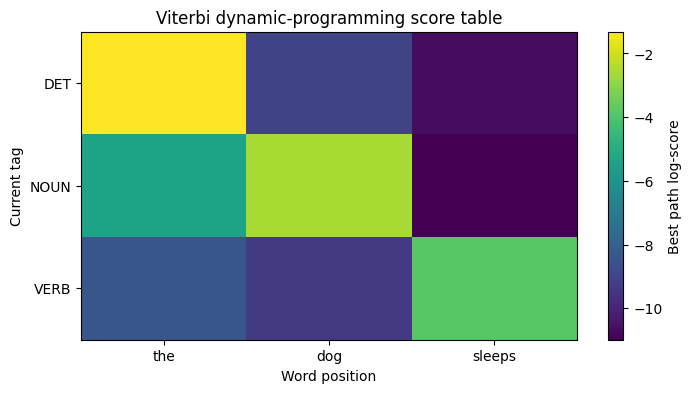

In [14]:
plt.figure(figsize=(8, 4))
plt.imshow(score_table.T, aspect='auto', cmap='viridis')
plt.xticks(range(len(sentence)), sentence)
plt.yticks(range(len(tags)), tags)
plt.colorbar(label='Best path log-score')
plt.xlabel('Word position')
plt.ylabel('Current tag')
plt.title('Viterbi dynamic-programming score table')
plt.show()

## 8. Forward versus Viterbi

- **Viterbi:** probability and path of the single most likely hidden sequence.
- **Forward algorithm:** sums probabilities over all hidden sequences to obtain $P(x_{1:T})$.
- **Forward-backward:** computes posterior probabilities for states at each position.

The difference between `max` and `sum` is conceptually crucial.

## 9. Limitations and historical importance

Bigram and HMM models make strong conditional-independence assumptions. They struggle with long-range context, sparse observations, semantic ambiguity, and complex morphology.

They remain valuable because they teach:

- explicit probabilistic modeling;
- sequence factorization;
- dynamic programming;
- smoothing and unknown events;
- decoding versus likelihood;
- the baseline ideas later generalized by RNNs and transformers.

## Exercises

1. Build a trigram language model and compare perplexity with the bigram model.
2. Add an `<UNK>` token and a principled train/test vocabulary split.
3. Implement interpolation between unigram and bigram probabilities.
4. Implement the HMM forward algorithm in log space.
5. Add adjective and adverb tags to the toy corpus.
6. Evaluate Viterbi predictions using held-out tagged sentences.
7. Explain why POS emissions are not truly independent of neighboring words given only the current tag.

## Key takeaways

- A Markov chain models transitions among observed states.
- A bigram LM is a first-order Markov model over words.
- Smoothing prevents unseen events from receiving zero probability.
- An HMM introduces hidden states that generate observations.
- Viterbi efficiently finds the most likely hidden-state path.
- These models build the probability and sequence foundations needed for later neural NLP.